In this notebook, we assess the stability of the clusters and their ability to predict the subphenotype (cluster) of new patients using a 5-fold cross-validation framework. We evaluated the consistency of clustering by computing the matching performance on 4/5 of the data (training set), and assessed the ability to assign subphenotypes to new patients using a K-Nearest Neighbors (KNN) classifier (with 25 neighbors and Euclidean distance).

Additionally, we evaluate the effect of using different KNN parameters on clustering assignment performance (test accuracy).

In [ ]:
library(yaml)
library(dplyr)
library(ggplot2)
library(reshape2)
library(tidyverse)
library(FSA) # perform dunn test
library(pheatmap)
Sys.setlocale("LC_ALL", "en_US.UTF-8") # for the plus_minus character
setwd("../")
source("scripts/procrustes_analysis_utils.r")
source("scripts/cluster_selection.r")
source('scripts/utils.r')
source('scripts/cross_validation.r')


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v forcats   1.0.0     v stringr   1.5.1
v lubridate 1.9.3     v tibble    3.2.1
v purrr     1.0.2     v tidyr     1.3.1
v readr     2.1.5     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'FSA' was built under R version 4.4.1"
## FSA v0.9.6. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.



[1] "en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/C"

Loading required package: cluster

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Warning message:
“package ‘clue’ was built under R version 4.4.1”
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘kknn’


The following object is masked from ‘package:caret’:

    contr.dummy




In [2]:
# Create a directory for the results
if (!dir.exists("outputs/hyperparameter_knn")) {
  dir.create("outputs/hyperparameter_knn")
}
output_path <- 'outputs/hyperparameter_knn/'
# Load the configuration file
config <- yaml::yaml.load_file("config.yml")
# Load the landmark coordinates data
df_coordinates <- read.csv(config$dataset$landmark_coordinates, check.names = FALSE, row.names = 1)
n_nearst_neighbours <- config$clustering_cross_validation$n_nearst_neighbours
n_nearst_neighbours

[1] 25

In [3]:
# Load the training data (caucasian population)

# Load the landmark coordinates data
df_coordinates <- read.csv(config$dataset$landmark_coordinates, check.names = FALSE, row.names = 1)

# Load the cephalometric measurments data
df_cepha_measurements <- read.csv(config$dataset$cephalometric_measurements, check.names = FALSE, row.names = 1)

# Load the patient information data
df_patient_info <- read.csv(config$dataset$patient_info, row.names = 1)

# Load Korean population data
df_coordinates_korean <- read.csv(config$dataset$landmark_coordinates_korean, check.names = FALSE, row.names = 1)

df_korean_patient_info <- read.csv(config$dataset$patient_info_korean)

df_korean_cepha_measurements <- read.csv(config$dataset$cephalometric_measurements_korean, check.names = FALSE, row.names = 1)

# Compute test performance considering different knn hyperparameters

In [4]:
# List of hyperparameters to be combined
knn_param_to_combine <- list(
    k = (n_nearst_neighbours-5):(n_nearst_neighbours+5),
    distance = c(1, 2),
    kernel = c("rectangular", "triangular", "biweight", "cos", "gaussian", "rank", "optimal")
)

# Perform cross-validation for KNN clustering
knn_hyperparameter_cv <- perform_cross_validation_knn(df = df_coordinates, cv_stratify_factors = as.factor(df_patient_info$Subpopulation), k = 6,  n_folds = 5, knn_param_to_combine = knn_param_to_combine, type="tan")
head(knn_hyperparameter_cv)

,mean_training,sd_training,mean_testing,sd_testing,fold_test_1,fold_test_2,fold_test_3,fold_test_4,fold_test_5,fold_train_1,fold_train_2,fold_train_3,fold_train_4,fold_train_5,k,distance,kernel,scale
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<lgl>
1,69.31301,4.659428,62.29168,7.917620,68.18182,64.12214,49.61832,60.30534,69.23077,73.42256,71.18321,63.9313,64.69466,73.33333,20,1,rectangular,FALSE
2,69.31301,4.659428,62.14018,8.041284,68.18182,62.59542,49.61832,60.30534,70.00000,73.42256,71.18321,63.9313,64.69466,73.33333,21,1,rectangular,FALSE
3,69.31301,4.659428,61.98518,8.589288,68.93939,62.59542,48.09160,61.06870,69.23077,73.42256,71.18321,63.9313,64.69466,73.33333,22,1,rectangular,FALSE
4,69.31301,4.659428,62.29285,8.618353,68.18182,63.35878,48.09160,61.83206,70.00000,73.42256,71.18321,63.9313,64.69466,73.33333,23,1,rectangular,FALSE
5,69.31301,4.659428,62.29401,8.180109,67.42424,63.35878,48.85496,61.83206,70.00000,73.42256,71.18321,63.9313,64.69466,73.33333,24,1,rectangular,FALSE
6,69.31301,4.659428,62.44552,8.019383,68.18182,63.35878,49.61832,61.06870,70.00000,73.42256,71.18321,63.9313,64.69466,73.33333,25,1,rectangular,FALSE


# Cross-validation test accuracies per knn hyperparameter set

In [5]:
# Prepare data 
df_result <- knn_hyperparameter_cv
df_result$row_id <- paste(df_result$k, df_result$kernel, sep= '-')

# Pivot longer: reshape from wide to long format
df_long <- df_result %>%
  pivot_longer(
    cols = starts_with("fold_test_"),
    names_to = "fold",
    values_to = "accuracy"
  )

df_long$distance <- recode(df_long$distance,
                                 `1` = "manhattan",
                                 `2` = "euclidean")

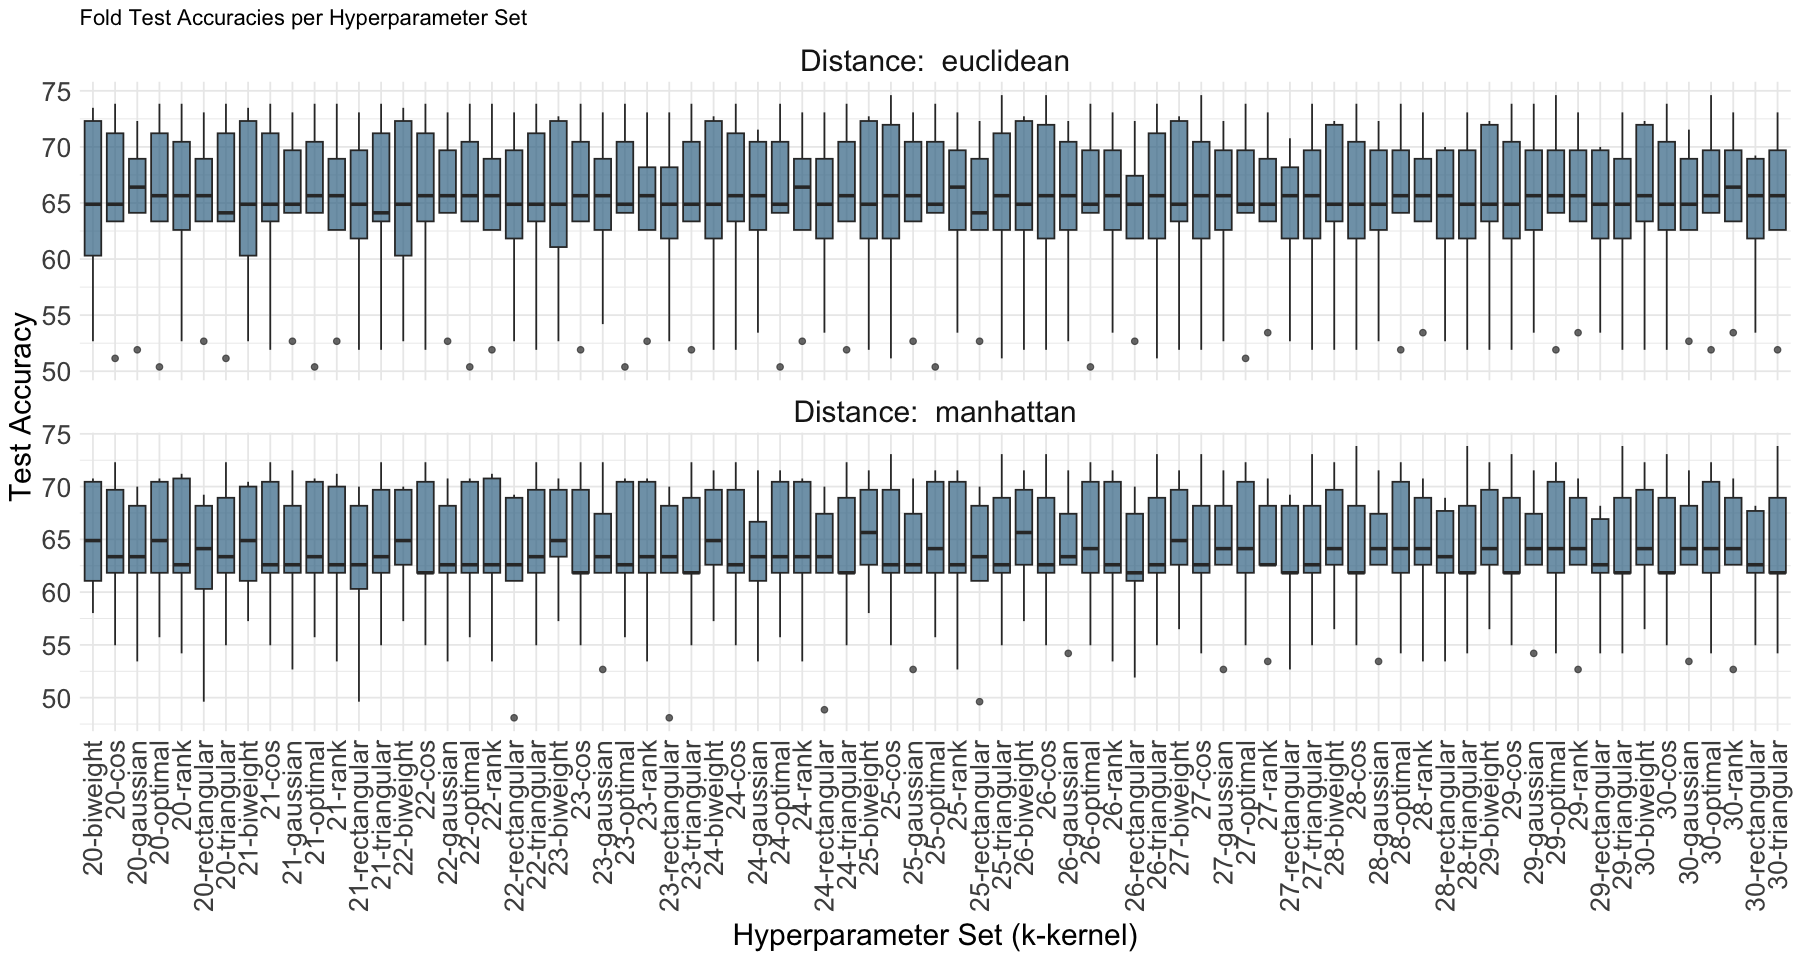

In [6]:
# Box plot of accuracies per parameter set
options(repr.plot.width=15, repr.plot.height=8)
cv_box_plot <- ggplot(df_long, aes(x = factor(row_id), y = accuracy)) +
  geom_boxplot(fill = "#3c7494", alpha = 0.7) +
  facet_wrap(~ paste('Distance: ',distance), scales = "free_y",nrow = 2) +
  labs(
    title = "Fold Test Accuracies per Hyperparameter Set",
    x = "Hyperparameter Set (k-kernel)",
    y = "Test Accuracy"
  ) +
  theme_minimal() +
   theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 16),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    strip.text = element_text(size = 18)  # facet labels
  )
ggsave(paste0(output_path, "test_acc_knn.pdf"), plot = cv_box_plot, width = 18, height = 10, dpi = 300)
cv_box_plot

# Does the knn hyperparameters selection affects the test accuracies?

In [13]:
df_result <- knn_hyperparameter_cv
df_result$row_id <- paste(df_result$k, df_result$distance, df_result$kernel, sep= '-')

# Pivot longer: reshape from wide to long format
df_long <- df_result %>%
  pivot_longer(
    cols = starts_with("fold_test_"),
    names_to = "fold",
    values_to = "accuracy"
  )

df_long$k <- as.factor(df_long$k)
df_long$distance <- as.factor(df_long$distance)
df_long$kernel <- as.factor(df_long$kernel)

In [14]:
aov_model <- aov(accuracy ~ distance * kernel * k, data = df_long)
summary(aov_model)

                   Df Sum Sq Mean Sq F value Pr(>F)
distance            1    101  100.51   1.765  0.185
kernel              6    184   30.67   0.538  0.779
k                  10      1    0.14   0.002  1.000
distance:kernel     6     63   10.56   0.185  0.981
distance:k         10      4    0.38   0.007  1.000
kernel:k           60     14    0.24   0.004  1.000
distance:kernel:k  60     21    0.35   0.006  1.000
Residuals         616  35090   56.96               

## ART

In [16]:
library(ARTool)

# Load library
library(ARTool)

# Fit ART model
m <- art(accuracy ~ distance * kernel * k, data = df_long)
# Run ANOVA
anova(m)


,Term,Df,Df.res,Sum Sq,Sum Sq.res,F value,Pr(>F)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
distance,distance,1,616,449347.014,37530157,7.375342528,0.006797938
kernel,kernel,6,616,351879.927,37558795,0.961860976,0.450265751
k,k,10,616,5675.343,37881910,0.009228709,0.999999998
distance:kernel,distance:kernel,6,616,42338.597,37873196,0.114771476,0.994694299
distance:k,distance:k,10,616,16710.629,37875113,0.027178129,0.999999644
kernel:k,kernel:k,60,616,56136.473,37833992,0.015233245,1.000000000
distance:kernel:k,distance:kernel:k,60,616,55218.649,37831708,0.014985088,1.000000000


## Dunn Test

In [9]:
dunn_test_result <- dunnTest(accuracy ~ as.factor(row_id), data = df_long, method = "bonferroni")
head(dunn_test_result$res)

,Comparison,Z,P.unadj,P.adj
,<chr>,<dbl>,<dbl>,<dbl>
1,20-1-biweight - 20-1-cos,0.05481547,0.9562855,1
2,20-1-biweight - 20-1-gaussian,0.34669004,0.7288242,1
3,20-1-cos - 20-1-gaussian,0.29187457,0.7703825,1
4,20-1-biweight - 20-1-optimal,-0.04556091,0.9636602,1
5,20-1-cos - 20-1-optimal,-0.10037638,0.9200455,1
6,20-1-gaussian - 20-1-optimal,-0.39225095,0.6948728,1


In [10]:
# Prepare data for Dunn's test into a matrix format
# Split the Comparison column into two separate columns
dunn_test_result$res  <- dunn_test_result$res %>%
  separate(Comparison, into = c("set 1", "set 2"), sep = " - ")
# Reshape to wide format for heatmap input
heatmap_data <- dunn_test_result$res %>%
  select(`set 1`, `set 2`, value = P.unadj) %>%
  pivot_wider(names_from = `set 2`, values_from = value)

# Convert to matrix
mat <- as.matrix(heatmap_data[,-1])
rownames(mat) <- heatmap_data$`set 1`
# Replace NA values with the corresponding values from the transpose (this is a symmetric matrix)
dunn_p_value_matrix <- mat
dunn_p_value_matrix[is.na(dunn_p_value_matrix)] <- t(mat)[is.na(mat)]

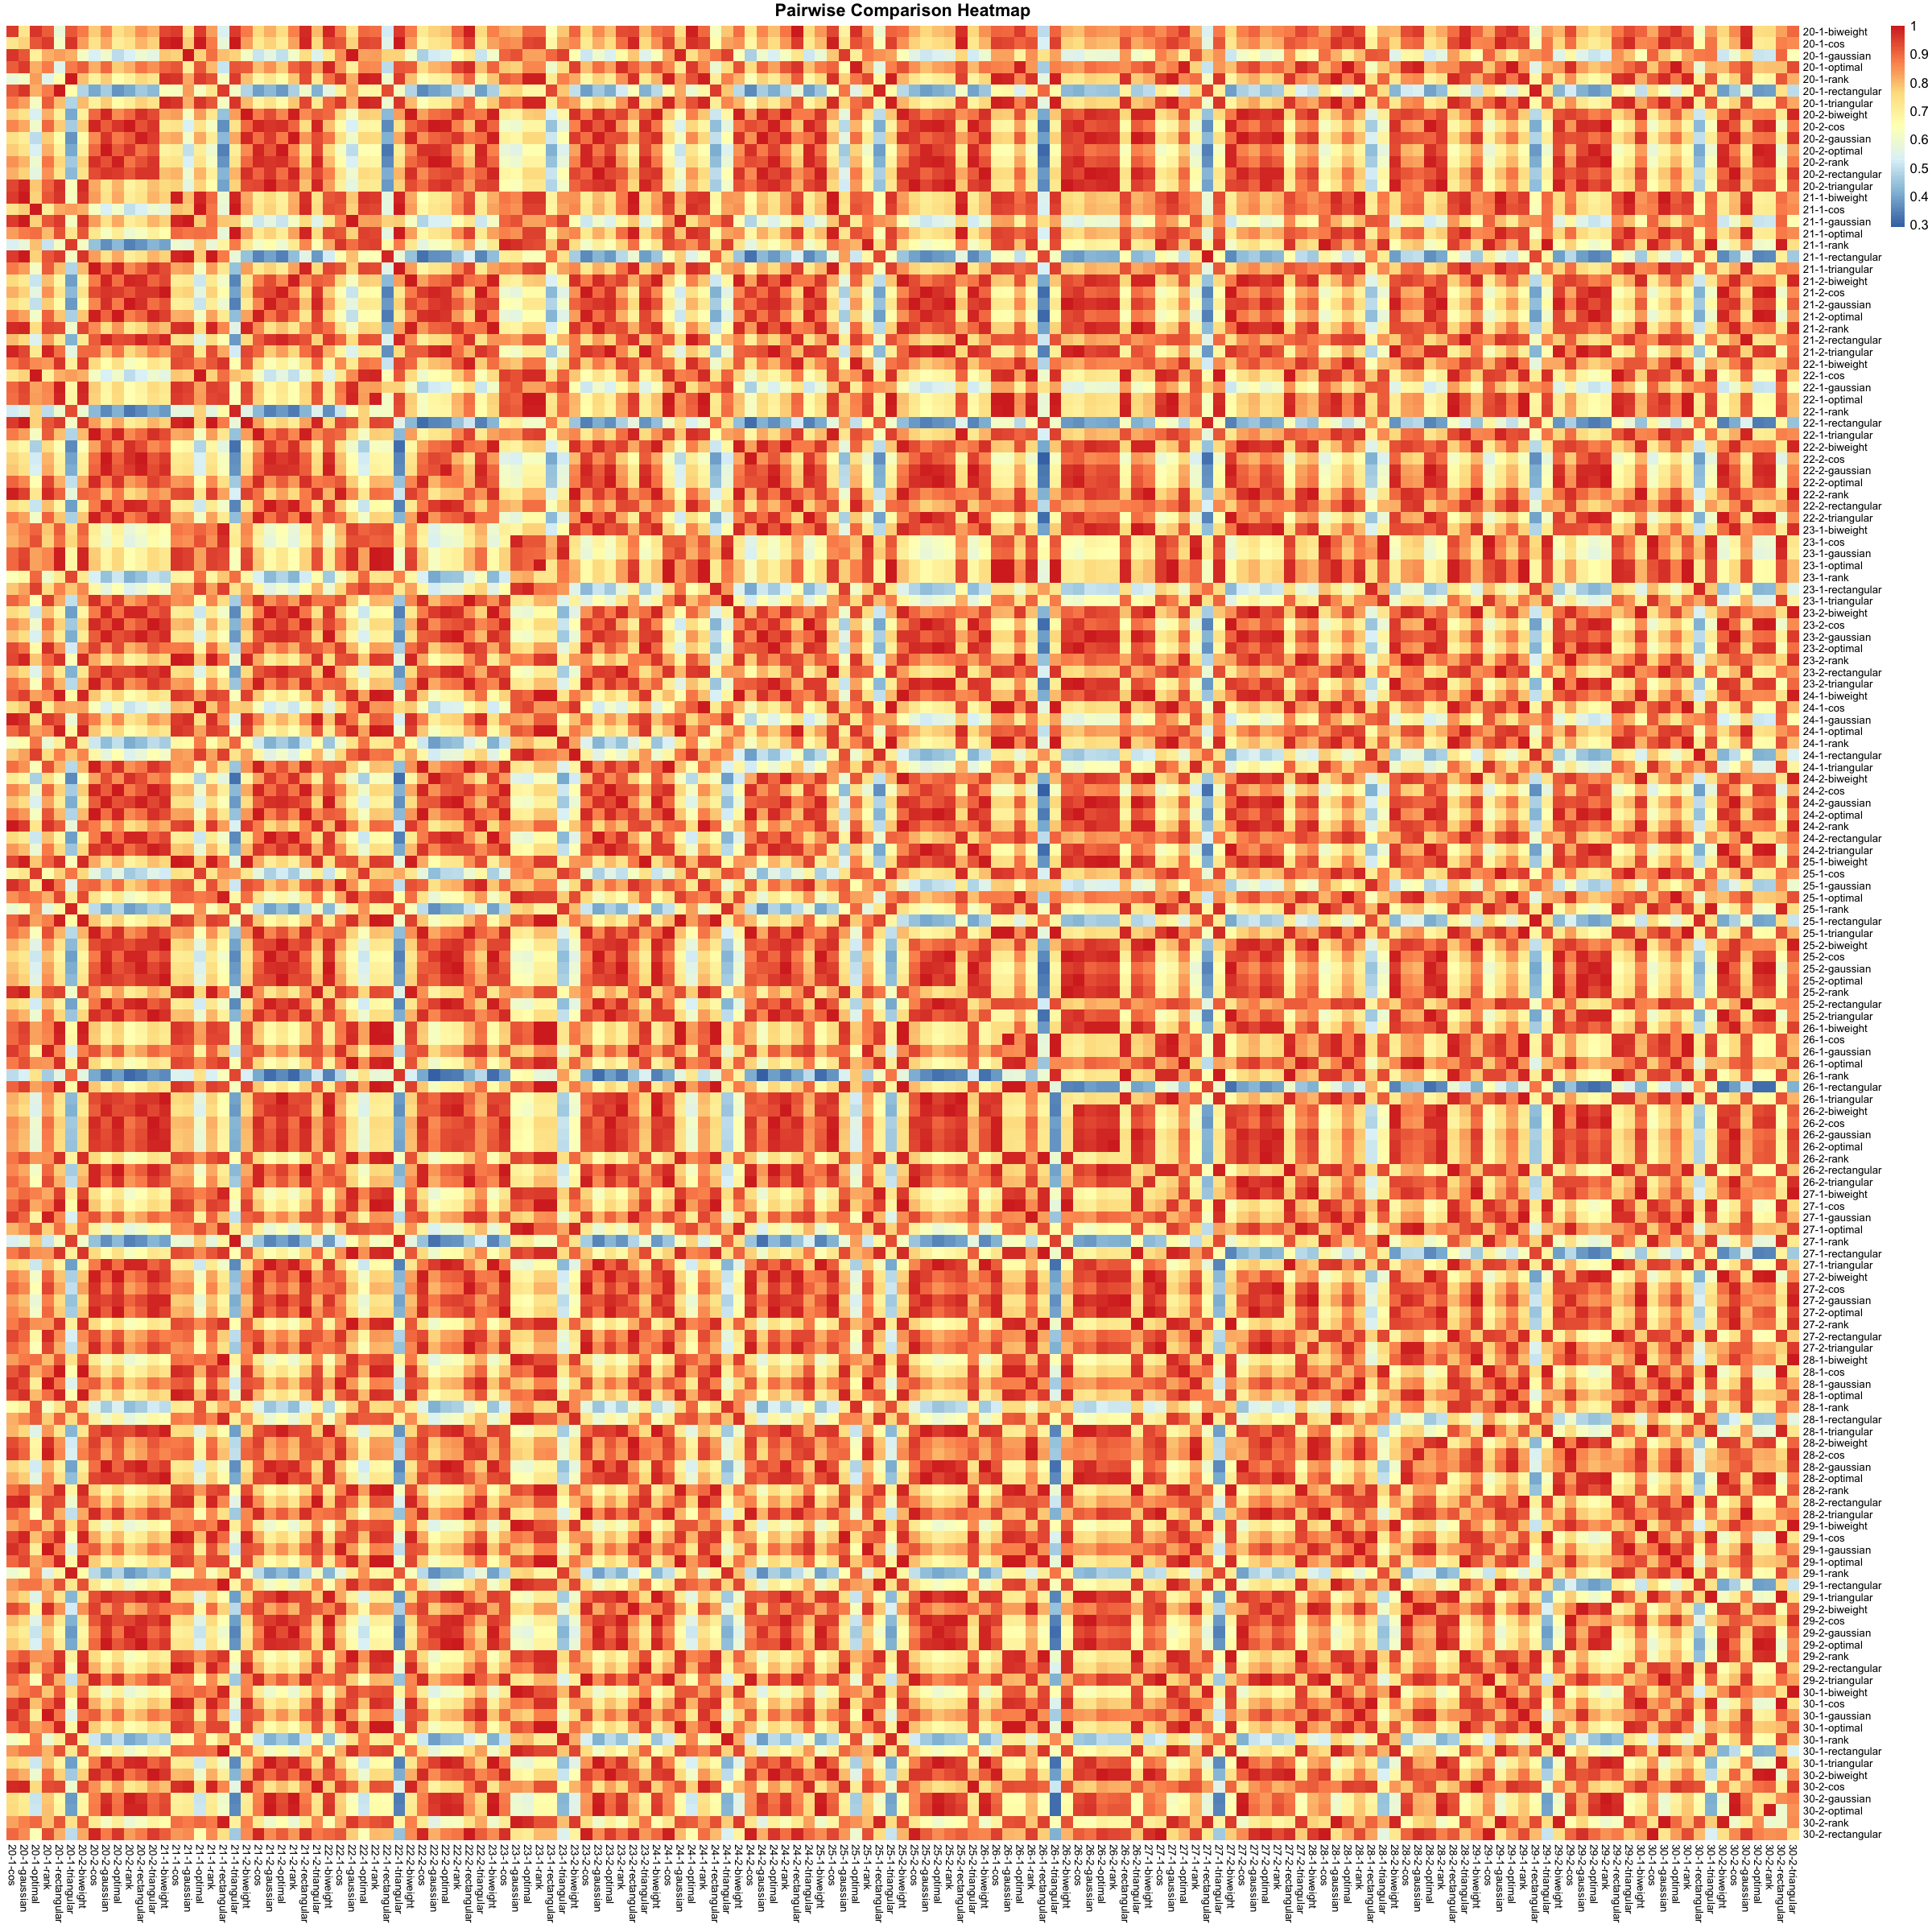

In [11]:
options(repr.plot.width=20, repr.plot.height=20)
pheatmap(dunn_p_value_matrix, cluster_rows = FALSE, cluster_cols = FALSE,
         display_numbers = FALSE, main = "Pairwise Comparison Heatmap"
         , fontsize_row = 8, fontsize_col = 8,
         )

In [12]:
# What is the minimum p-value in the Dunn's test result?
min(dunn_p_value_matrix)

[1] 0.291742

Large p-value (e.g., > 0.05) → Not enough evidence to reject the null.

No significant difference between the groups.

Changing hyperparameters doesn't significantly affect overall model performance.